# Generate plots for features used in contamination detector

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from cytodataframe import CytoDataFrame
from plotnine import (
    aes,
    element_text,
    geom_density,
    ggplot,
    labs,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from sklearn.preprocessing import StandardScaler

from cosmicqc import find_outliers

In [2]:
# Directory with data
data_dir = Path(
    "/media/18tbdrive/1.Github_Repositories/nf1_schwann_cell_painting_data/3.processing_features/data/converted_data"
)

# Directory to save cleaned data
figure_dir = Path("./figures")
figure_dir.mkdir(exist_ok=True)

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

In [3]:
# Load in converted plate data
plate_df = pd.read_parquet(f"{data_dir}/Plate_3.parquet")

print(plate_df.shape)
plate_df.head()

(18038, 2321)


,Metadata_ImageNumber,Image_Metadata_Plate,Metadata_number_of_singlecells,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Image_FileName_CY5,...,Nuclei_Texture_Variance_DAPI_3_02_256,Nuclei_Texture_Variance_DAPI_3_03_256,Nuclei_Texture_Variance_GFP_3_00_256,Nuclei_Texture_Variance_GFP_3_01_256,Nuclei_Texture_Variance_GFP_3_02_256,Nuclei_Texture_Variance_GFP_3_03_256,Nuclei_Texture_Variance_RFP_3_00_256,Nuclei_Texture_Variance_RFP_3_01_256,Nuclei_Texture_Variance_RFP_3_02_256,Nuclei_Texture_Variance_RFP_3_03_256
0,2,Plate_3,84,11,B10,1,1,2,2,B10_01_3_11_CY5_001_illumcorrect.tiff,...,3103.378595,2928.440215,1289.387179,1113.191261,1143.798104,1229.706291,1860.427125,1792.018063,1751.963638,1860.317249
1,5,Plate_3,84,14,B10,1,1,2,2,B10_01_3_14_CY5_001_illumcorrect.tiff,...,674.346209,687.648994,38.764372,40.170070,40.270733,37.789788,101.849116,99.378570,99.875012,98.784846
2,12,Plate_3,84,20,B10,1,1,2,2,B10_01_3_20_CY5_001_illumcorrect.tiff,...,1566.205750,1486.305372,279.656989,270.323458,300.199086,289.428542,189.134603,192.120194,188.116851,187.663065
3,13,Plate_3,84,21,B10,1,1,2,2,B10_01_3_21_CY5_001_illumcorrect.tiff,...,544.841379,546.635939,35.728497,37.452466,34.925836,34.609601,84.199793,86.931665,85.634432,82.349088
4,14,Plate_3,84,22,B10,1,1,2,2,B10_01_3_22_CY5_001_illumcorrect.tiff,...,1001.824339,979.699936,85.783028,82.215142,84.944425,100.984105,226.980762,230.125834,230.609025,226.963522


In [4]:
# compartment for bounding boxes
compartment = "Cytoplasm"

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_FileName_DAPI",
    "Image_PathName_DAPI",
    f"{compartment}_AreaShape_BoundingBoxMaximum_X",
    f"{compartment}_AreaShape_BoundingBoxMaximum_Y",
    f"{compartment}_AreaShape_BoundingBoxMinimum_X",
    f"{compartment}_AreaShape_BoundingBoxMinimum_Y",
]

# find irregular shaped nuclei
feature_thresholds = {
    # outlier threshold for only cytoplasm texture in nuclei channel
    "Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256": 1,
}

irregular_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=feature_thresholds,
)

irregular_nuclei_outliers_cdf = CytoDataFrame(
    data=irregular_nuclei_outliers,
)[
    [
        "Image_FileName_DAPI",
        "Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Image_Metadata_Plate",
    ]
]

Number of outliers: 3028 (16.79%)
Outliers Range:
Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256 Min: -0.3386040270682621
Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256 Max: 0.0


In [5]:
# find irregular shaped nuclei
feature_thresholds = {
    # outlier threshold for only cytoplasm granularity in nuclei channel
    "Cytoplasm_Granularity_2_DAPI": 1,
}

granularity_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=feature_thresholds,
)

granularity_nuclei_outliers_cdf = CytoDataFrame(
    data=granularity_nuclei_outliers,
)[
    [
        "Image_FileName_DAPI",
        "Cytoplasm_Granularity_2_DAPI",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Image_Metadata_Plate",
    ]
]

Number of outliers: 2269 (12.58%)
Outliers Range:
Cytoplasm_Granularity_2_DAPI Min: 1.9138818048921382
Cytoplasm_Granularity_2_DAPI Max: 27.639655282904474


In [6]:
# Add QC_status column to plate_df for irregular nuclei outliers only
plate_df["QC_status"] = "Single-cell passed QC"
plate_df.loc[list(irregular_nuclei_outliers.index), "QC_status"] = (
    "Single-cell failed QC"
)

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 7 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/texture_distribution_plot.png


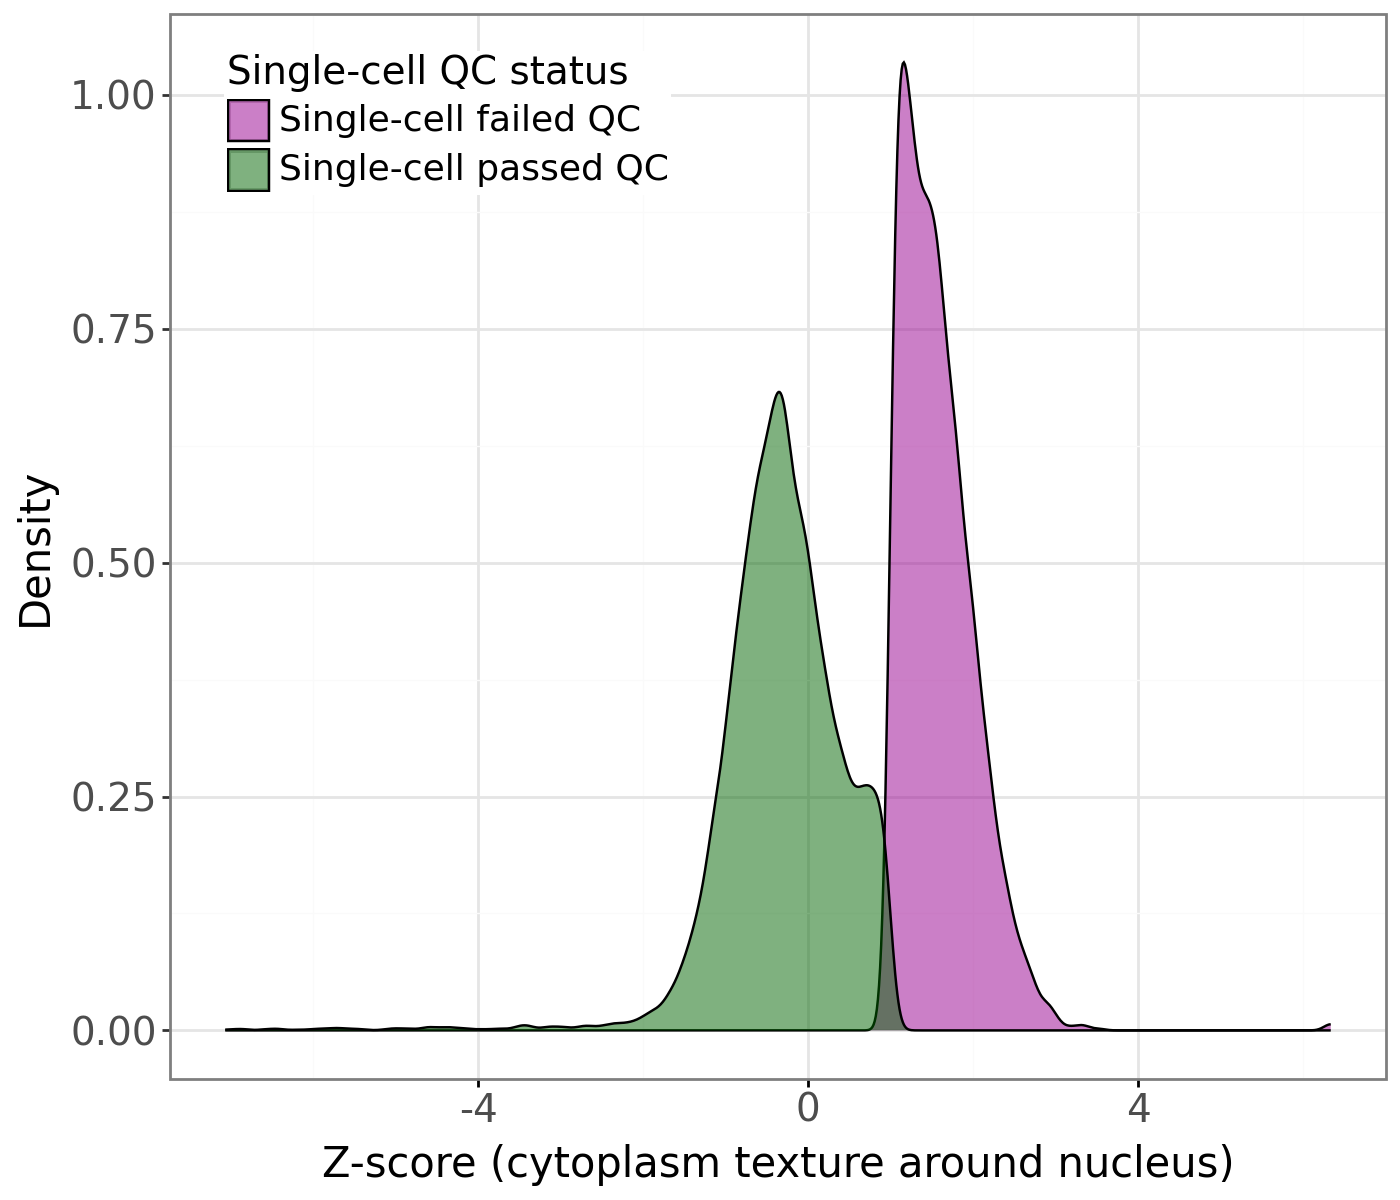

In [7]:
# Z-score normalize the cytoplasm texture for plotting
scaler = StandardScaler()
plate_df[["Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256"]] = scaler.fit_transform(
    plate_df[["Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256"]]
)

# Define colors
fill_colors = {"Single-cell passed QC": "#006400", "Single-cell failed QC": "#990090"}

# Set the figure size
height = 6
width = 7
set_option("figure_size", (width, height))

# Create the density plot
p = (
    ggplot(
        plate_df, aes(x="Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256", fill="QC_status")
    )
    + geom_density(alpha=0.5)
    + scale_fill_manual(values=fill_colors)
    + labs(
        x="Z-score (cytoplasm texture around nucleus)",
        y="Density",
        fill="Single-cell QC status",
    )
    + theme_bw()
    + theme(
        legend_position=(0.07, 0.96),
        legend_title=element_text(size=14),
        legend_text=element_text(size=13),
        axis_title=element_text(size=15),
        axis_text=element_text(size=14),
    )
)

# Save the plot
p.save(
    figure_dir / "texture_distribution_plot.png",
    dpi=600,
    width=width,
    height=height,
)

# Show plot
p.show()

In [8]:
# Add QC_status column to plate_df for granularity nuclei outliers only
plate_df["QC_status"] = "Single-cell passed QC"
plate_df.loc[list(granularity_nuclei_outliers_cdf.index), "QC_status"] = (
    "Single-cell failed QC"
)

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 7 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/granularity_distribution_plot.png
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_density : Removed 13149 rows containing non-finite values.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_density : Removed 13149 rows containing non-finite values.


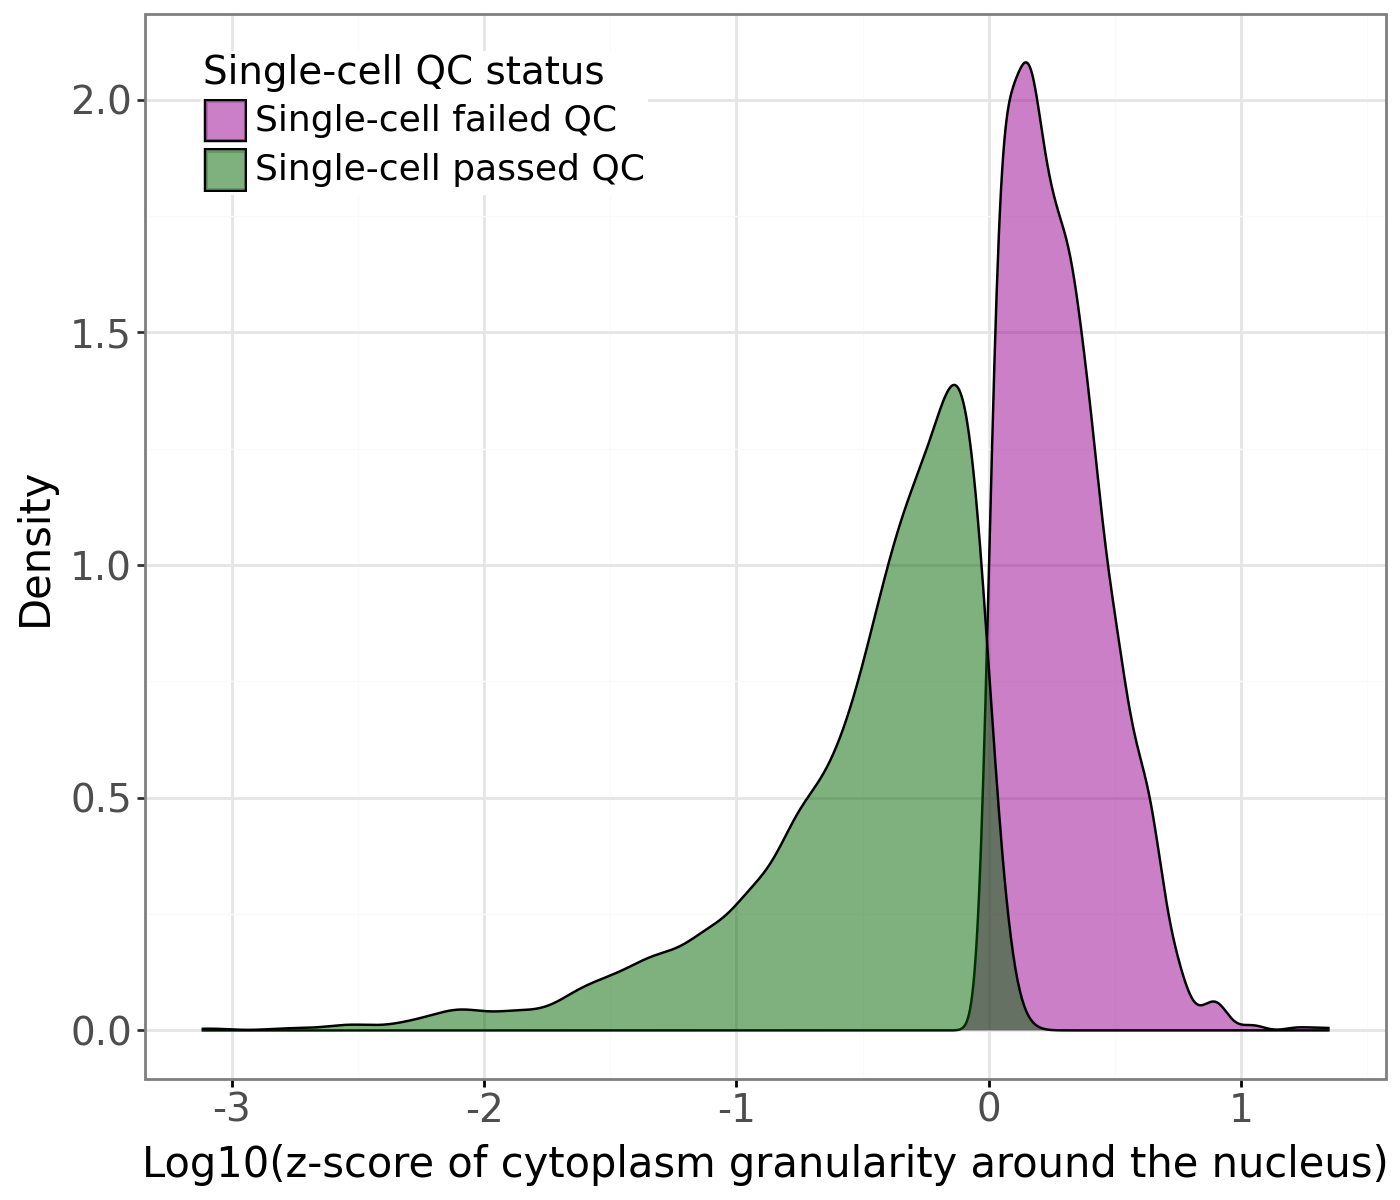

In [9]:
scaler = StandardScaler()
plate_df[["Cytoplasm_Granularity_2_DAPI"]] = scaler.fit_transform(
    plate_df[["Cytoplasm_Granularity_2_DAPI"]]
)

# Take log10 of the cytoplasm granularity
plate_df["Log_Cytoplasm_Granularity"] = np.log10(
    plate_df["Cytoplasm_Granularity_2_DAPI"]
)


# Define colors
fill_colors = {"Single-cell passed QC": "#006400", "Single-cell failed QC": "#990090"}

# Set the figure size
height = 6
width = 7
set_option("figure_size", (width, height))

# Create the density plot
p = (
    ggplot(plate_df, aes(x="Log_Cytoplasm_Granularity", fill="QC_status"))
    + geom_density(alpha=0.5)
    + scale_fill_manual(values=fill_colors)
    + labs(
        x="Log10(z-score of cytoplasm granularity around the nucleus)",
        y="Density",
        fill="Single-cell QC status",
    )
    + theme_bw()
    + theme(
        legend_position=(0.07, 0.96),
        legend_title=element_text(size=14),
        legend_text=element_text(size=13),
        axis_title=element_text(size=15),
        axis_text=element_text(size=14),
    )
)

# Save the plot
p.save(
    figure_dir / "granularity_distribution_plot.png",
    dpi=600,
    width=width,
    height=height,
)

# Show plot
p.show()